In [1]:
import pandas as pd
import numpy as np

caminho = "datasets/raw/MQTT/"
print("A carregar e a rotular os dados...")

# Tráfego Normal
df_normal = pd.read_csv(caminho + "biflow_normal.csv")
df_normal['Label_Binario'] = 0
df_normal['Classe'] = 'Normal'

# Tráfego Malicioso
df_bruteforce = pd.read_csv(caminho + "biflow_mqtt_bruteforce.csv")
df_bruteforce['Label_Binario'] = 1
df_bruteforce['Classe'] = 'Bruteforce_MQTT'

df_scan_A = pd.read_csv(caminho + "biflow_scan_A.csv")
df_scan_A['Label_Binario'] = 1
df_scan_A['Classe'] = 'Scan_A'

df_scan_sU = pd.read_csv(caminho + "biflow_scan_sU.csv")
df_scan_sU['Label_Binario'] = 1
df_scan_sU['Classe'] = 'Scan_UDP'

df_sparta = pd.read_csv(caminho + "biflow_sparta.csv")
df_sparta['Label_Binario'] = 1
df_sparta['Classe'] = 'Sparta_Composto'

# Consolidar
dataset = pd.concat([df_normal, df_bruteforce, df_scan_A, df_scan_sU, df_sparta], ignore_index=True)
print(f"Dataset consolidado: {dataset.shape[0]} pacotes.")

A carregar e a rotular os dados...
Dataset consolidado: 259379 pacotes.


In [2]:
print("A verificar a integridade matemática dos dados...")

# Substituir infinitos por NaN e limpar
dataset = dataset.replace([np.inf, -np.inf], np.nan)
valores_corrompidos = dataset.isnull().sum().sum()

if valores_corrompidos > 0:
    dataset_limpo = dataset.dropna()
    print(f"Limpeza feita! Apagámos {valores_corrompidos} erros.")
else:
    dataset_limpo = dataset
    print("✅ O dataset está perfeitamente limpo.")

A verificar a integridade matemática dos dados...
✅ O dataset está perfeitamente limpo.


In [3]:
from sklearn.model_selection import train_test_split

print("A preparar os dados de Treino e Teste...")

# Remover as respostas e os identificadores que "viciam" a IA
colunas_a_remover = ['ip_src', 'ip_dst', 'prt_src', 'prt_dst', 'proto', 'is_attack', 'Label_Binario', 'Classe']

X = dataset_limpo.drop(columns=colunas_a_remover)
y = dataset_limpo['Classe']

# Divisão 80/20 com proporção mantida (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"O modelo vai estudar com {X_train.shape[0]} pacotes e ser testado com {X_test.shape[0]}.")

A preparar os dados de Treino e Teste...
O modelo vai estudar com 207503 pacotes e ser testado com 51876.


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

print("A normalizar e a treinar o modelo base (Baseline)...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

inicio = time.time()
modelo_rf.fit(X_train_scaled, y_train)
fim = time.time()

previsoes = modelo_rf.predict(X_test_scaled)
print(f"Treino base (100 árvores) concluído em {round(fim - inicio, 2)} segundos!")
print(f"Precisão Base: {accuracy_score(y_test, previsoes) * 100:.2f}%")

A normalizar e a treinar o modelo base (Baseline)...
Treino base (100 árvores) concluído em 16.56 segundos!
Precisão Base: 77.22%


A desenhar o cérebro da Inteligência Artificial...


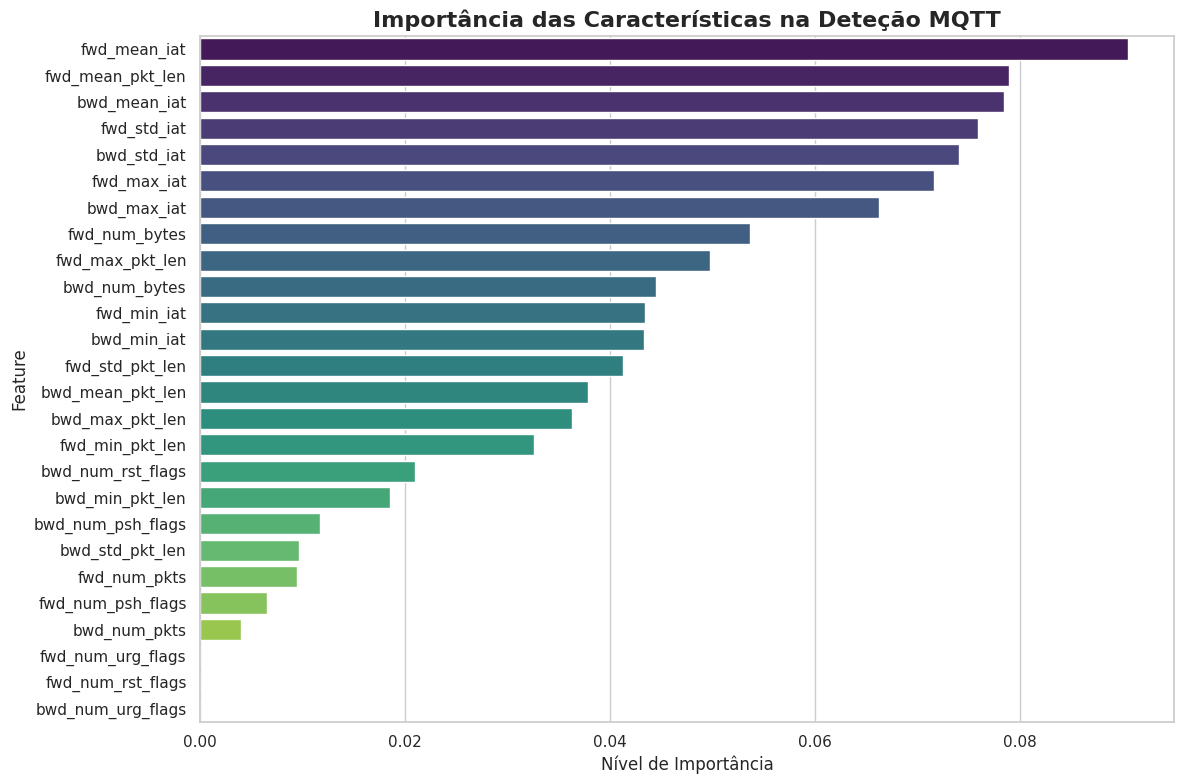

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("A desenhar o cérebro da Inteligência Artificial...")

importancias = modelo_rf.feature_importances_
df_importancias = pd.DataFrame({'Caracteristica': X.columns, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.barplot(x='Importancia', y='Caracteristica', data=df_importancias, hue='Caracteristica', legend=False, palette='viridis')

plt.title('Importância das Características na Deteção MQTT', fontsize=16, fontweight='bold')
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
print("A treinar o modelo VIP (Eficiência Máxima - Apenas 15 Features)...")

top_15_features = df_importancias.head(15)['Caracteristica'].tolist()

X_train_vip = X_train[top_15_features]
X_test_vip = X_test[top_15_features]

scaler_vip = StandardScaler()
X_train_scaled_vip = scaler_vip.fit_transform(X_train_vip)
X_test_scaled_vip = scaler_vip.transform(X_test_vip)

# O Modelo Otimizado
modelo_rf_vip = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo_rf_vip.fit(X_train_scaled_vip, y_train)

previsoes_vip = modelo_rf_vip.predict(X_test_scaled_vip)
print(f"Precisão do Modelo VIP: {accuracy_score(y_test, previsoes_vip) * 100:.2f}%")
print(classification_report(y_test, previsoes_vip))

A treinar o modelo VIP (Eficiência Máxima - Apenas 15 Features)...
Precisão do Modelo VIP: 77.29%
                 precision    recall  f1-score   support

Bruteforce_MQTT       0.99      0.95      0.97      3339
         Normal       0.68      0.78      0.73     17202
         Scan_A       0.99      0.78      0.87      5138
       Scan_UDP       0.85      0.68      0.76      7933
Sparta_Composto       0.75      0.77      0.76     18264

       accuracy                           0.77     51876
      macro avg       0.85      0.79      0.82     51876
   weighted avg       0.78      0.77      0.78     51876



In [7]:
from sklearn.model_selection import RandomizedSearchCV

print("A gerar a prova científica do limite do algoritmo na amostra...")

X_amostra, _, y_amostra, _ = train_test_split(
    X_train_scaled_vip, y_train, train_size=0.20, stratify=y_train, random_state=42
)

parametros_grelha = {
    'n_estimators': [100, 200],          
    'max_depth': [None, 20, 30],         
    'min_samples_split': [2, 5],         
    'criterion': ['gini', 'entropy'],    
    'class_weight': ['balanced', None]   
}

procura_aleatoria = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=2),
    param_distributions=parametros_grelha,
    n_iter=10, cv=3, random_state=42, n_jobs=2
)

procura_aleatoria.fit(X_amostra, y_amostra)
print(f"Melhor configuração possível testada: {procura_aleatoria.best_params_}")
# Não vamos sobrepor o nosso modelo VIP com este, guardamos apenas a métrica visual abaixo.

A gerar a prova científica do limite do algoritmo na amostra...
Melhor configuração possível testada: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None, 'criterion': 'gini', 'class_weight': None}


In [8]:
import joblib
import os

print("A preparar a exportação da Inteligência Artificial (Padrão de Ouro)...")

# Criar a pasta
os.makedirs('modelos_treinados', exist_ok=True)

# Guardar o Modelo (O Modelo Random Forest)
caminho_modelo = 'modelos_treinados/random_forest_mqtt.joblib'
joblib.dump(modelo_rf_vip, caminho_modelo)
print(f"Modelo guardado em segurança: {caminho_modelo}")

# Guardar a "Régua" (O Normalizador). Crucial para a plataforma web
caminho_scaler = 'modelos_treinados/scaler_mqtt.joblib'
joblib.dump(scaler_vip, caminho_scaler)
print(f"Normalizador guardado em segurança: {caminho_scaler}")

A preparar a exportação da Inteligência Artificial (Padrão de Ouro)...
Modelo guardado em segurança: modelos_treinados/random_forest_mqtt.joblib
Normalizador guardado em segurança: modelos_treinados/scaler_mqtt.joblib
